In [1]:
!pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 2/2 [kagglehub]



In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shuofxz/titanic-machine-learning-from-disaster")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Jitto\.cache\kagglehub\datasets\shuofxz\titanic-machine-learning-from-disaster\versions\1


In [2]:
import pandas as pd

In [7]:
%pip install opendatasets --upgrade


   ---------------------------------------- 2/2 [opendatasets]

Note: you may need to restart the kernel to use updated packages.


In [11]:
train_df = pd.read_csv('./data/titanic-archive/train.csv')
test_df = pd.read_csv('./data/titanic-archive/test.csv')

In [12]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [16]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
train_df['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
         ..
36.50     1
55.50     1
0.92      1
23.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [18]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='count'>

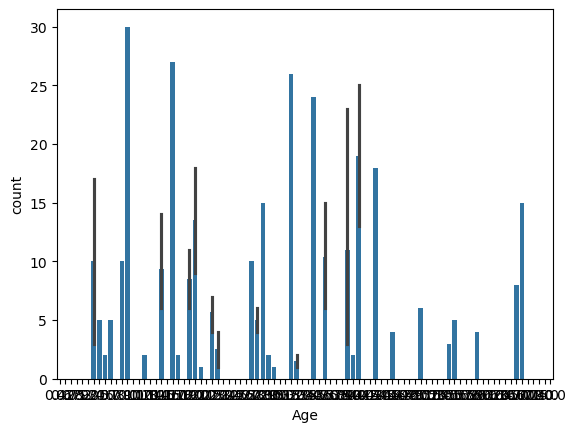

In [19]:
sns.barplot(x='Age', y=train_df['Age'].value_counts(), data=train_df)

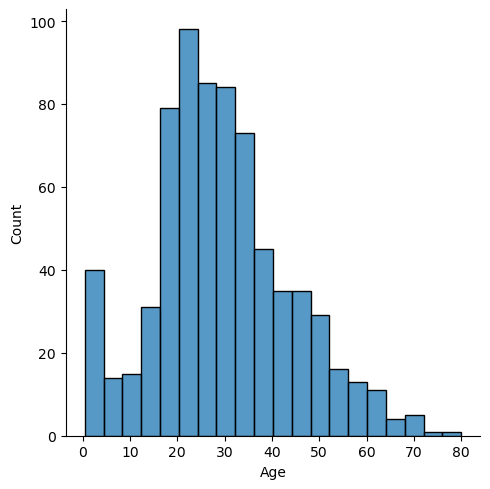

In [23]:
sns.displot(train_df['Age'])

<Axes: xlabel='Age', ylabel='Count'>

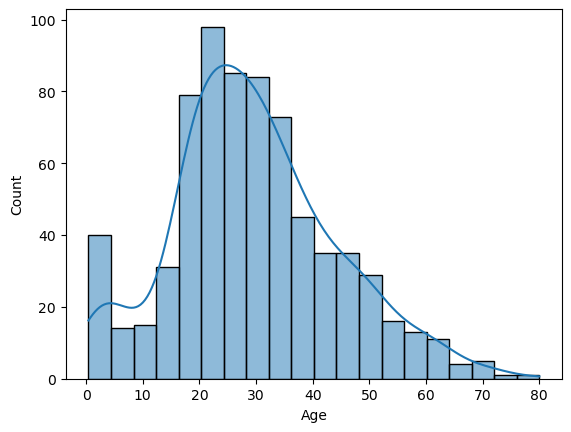

In [25]:
sns.histplot(train_df['Age'], kde=True)

In [41]:
train_df['age_median'] = train_df['Age'].fillna(train_df['Age'].median())

In [44]:
train_df['age_mean'] = train_df['Age'].fillna(train_df['Age'].mean())

<Axes: xlabel='age_median', ylabel='Count'>

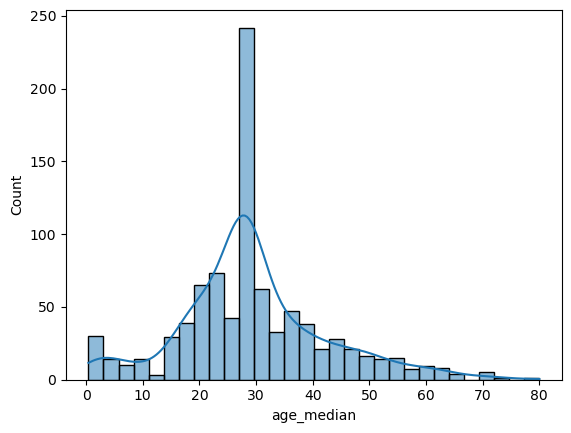

In [42]:
sns.histplot(train_df['age_median'], kde=True)

<Axes: xlabel='age_mean', ylabel='Count'>

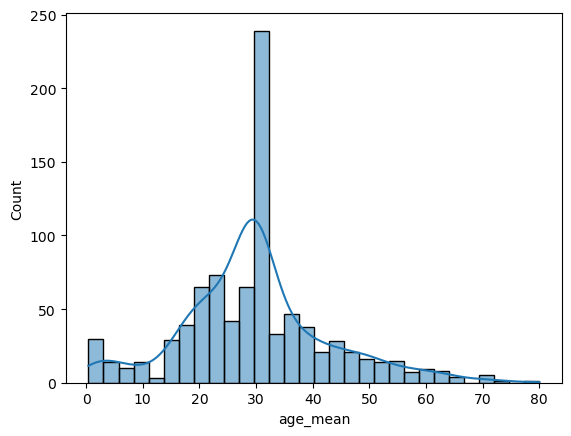

In [45]:
sns.histplot(train_df['age_mean'], kde=True)

In [40]:
train_df['Age'].fillna(train_df['Age'].mode()).isna().sum()

np.int64(177)

In [47]:
train_df.drop(columns=['age_mean', 'Age_mode'], inplace=True)

In [49]:
train_df.dtypes==object

PassengerId    False
Survived       False
Pclass         False
Name            True
Sex             True
Age            False
SibSp          False
Parch          False
Ticket          True
Fare           False
Cabin           True
Embarked        True
age_median     False
dtype: bool

In [53]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'age_median'],
      dtype='object')

In [54]:
object_columns = train_df.dtypes[train_df.dtypes == 'object'].index.tolist()

In [55]:
object_columns

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [56]:
train_df.drop(columns='Name', inplace = True)

In [57]:
object_columns = train_df.dtypes[train_df.dtypes == 'object'].index.tolist()

In [59]:
object_columns

['Sex', 'Ticket', 'Cabin', 'Embarked']

In [92]:
train_df['Embarked'] = train_df['Embarked'].fillna(train_df[train_df['Embarked'].notna()]['Embarked'].mode()[0])

In [93]:
train_df[object_columns].isna().sum()

Sex           0
Ticket        0
Cabin       687
Embarked      0
dtype: int64

In [71]:
train_df[train_df['Embarked'].notna()]['Embarked']

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [79]:
train_df['Embarked'].shape

(891,)

In [82]:
train_df['Embarked'].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: Embarked, Length: 891, dtype: bool

In [89]:
train_df[train_df['Embarked'].notna()]['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [95]:
train_df.drop(columns='Cabin').columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked', 'age_median'],
      dtype='object')

In [106]:
train_df.dtypes[train_df.dtypes == 'object'].index.tolist()

['Sex', 'Embarked']

KeyError: "['Cabin'] not found in axis"